# Pennsylvania Severe Weather Atlas
## Notebook 04 — County Patterns and Mapping

### Purpose

Explore where Pennsylvania's reported Thunderstorm Wind, Hail, and Tornado records were concentrated during 2011–2025, with a closer look at Lehigh and Northampton counties.

### Goals

1. Load the prepared historical event dataset.
2. Validate county identifiers against official county boundaries.
3. Summarize and map records by county and event type.
4. Highlight the Lehigh Valley and save the geographic outputs.

### Unit of analysis

We are counting reported event records assigned to each county. These maps will describe the geographic distribution of records in our dataset.

### Imports and environment check

GeoPandas will handle county boundaries and geographic data. We will use pandas for summary tables and Matplotlib for charts and maps.

The next cell loads our tools, displays the Python interpreter, and reports the installed GeoPandas version.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import sys
import hashlib
import zipfile

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

from matplotlib.colors import Normalize
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator

print("Python:", sys.version.split()[0])
print("Interpreter:", sys.executable)
print("Virtual environment:", sys.prefix != sys.base_prefix)
print("GeoPandas:", gpd.__version__)
print("Notebook 4 imports loaded successfully.")

Python: 3.13.5
Interpreter: c:\Users\rcolo\OneDrive\Desktop\Pennsylvania-Severe-Weather-Atlas\.venv\Scripts\python.exe
Virtual environment: True
GeoPandas: 1.1.4
Notebook 4 imports loaded successfully.


### Environment check results

Notebook 4 is using Python 3.13.5 from this project's `.venv` environment.

GeoPandas 1.1.4 and the other notebook imports loaded successfully.

## Loading the prepared event records

We will reload the historical dataset prepared in Notebook 2 and define the folders for boundaries, tables, figures, and map files.

County FIPS codes will be read as text because they are identifiers. These codes will connect our event records to the county boundaries.

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROJECT_PATHS = {
    "processed": PROJECT_ROOT / "data" / "processed",
    "boundaries": PROJECT_ROOT / "data" / "external" / "boundaries",
    "figures": PROJECT_ROOT / "reports" / "figures",
    "tables": PROJECT_ROOT / "reports" / "tables",
    "maps": PROJECT_ROOT / "outputs" / "maps",
}

dataset_path = (
    PROJECT_PATHS["processed"] / "pa_focus_events_2011_2025.csv"
)

pa_focus_events = pd.read_csv(
    dataset_path,
    dtype={
        "county_fips": "string",
        "is_lehigh_valley": "boolean",
        "hail_ge_1in": "boolean",
        "wind_ge_50kt": "boolean",
    },
    parse_dates=["begin_datetime"],
    low_memory=False,
)

print("Project root:", PROJECT_ROOT)
print(f"Rows: {len(pa_focus_events):,}")
print("Columns:", pa_focus_events.shape[1])
print(
    "Year range:",
    pa_focus_events["event_year"].min(),
    "to",
    pa_focus_events["event_year"].max(),
)
print("Distinct county identifiers:", pa_focus_events["county_fips"].nunique())
print(f"Lehigh Valley records: {pa_focus_events['is_lehigh_valley'].sum():,}")

pa_focus_events[
    ["county_fips", "CZ_NAME", "EVENT_TYPE", "event_year"]
].head()

Project root: c:\Users\rcolo\OneDrive\Desktop\Pennsylvania-Severe-Weather-Atlas
Rows: 15,399
Columns: 60
Year range: 2011 to 2025
Distinct county identifiers: 67
Lehigh Valley records: 564


,county_fips,CZ_NAME,EVENT_TYPE,event_year
0,42085,MERCER,Thunderstorm Wind,2011
1,42031,CLARION,Thunderstorm Wind,2011
2,42129,WESTMORELAND,Hail,2011
3,42007,BEAVER,Hail,2011
4,42085,MERCER,Hail,2011


### Prepared dataset loaded

The dataset contains 15,399 records and 60 columns covering 2011–2025, with 67 distinct county identifiers and 564 Lehigh Valley records.

These counts match our previous notebook. County identifiers repeat because each county can have multiple event records; we will aggregate those records before mapping.

## Downloading county boundaries

We will use the Census Bureau's 2025 county boundary release as the map reference for our 2011–2025 event records.

The national boundary ZIP will be saved in `data/external/boundaries`. The code will reuse an existing file and check the archive for corruption.

Afterward, we will load the boundaries and select Pennsylvania.

In [3]:
BOUNDARY_YEAR = 2025
boundary_filename = f"cb_{BOUNDARY_YEAR}_us_county_500k.zip"
boundary_url = (
    f"https://www2.census.gov/geo/tiger/GENZ{BOUNDARY_YEAR}/shp/"
    f"{boundary_filename}"
)

PROJECT_PATHS["boundaries"].mkdir(parents=True, exist_ok=True)
boundary_path = PROJECT_PATHS["boundaries"] / boundary_filename

candidate_path = boundary_path
boundary_status = "reused"

if not boundary_path.exists():
    candidate_path = boundary_path.with_suffix(".zip.part")
    boundary_response = requests.get(boundary_url, timeout=120)
    boundary_response.raise_for_status()
    candidate_path.write_bytes(boundary_response.content)
    boundary_status = "downloaded"

with zipfile.ZipFile(candidate_path) as archive:
    damaged_member = archive.testzip()
    if damaged_member is not None:
        raise ValueError(f"Damaged archive member: {damaged_member}")
    boundary_contents = archive.namelist()

if candidate_path != boundary_path:
    candidate_path.replace(boundary_path)

print("Boundary file:", boundary_path)
print("Status:", boundary_status)
print(f"File size: {boundary_path.stat().st_size:,} bytes")
print("ZIP integrity check: passed")

pd.DataFrame({"file_in_archive": boundary_contents})

Boundary file: c:\Users\rcolo\OneDrive\Desktop\Pennsylvania-Severe-Weather-Atlas\data\external\boundaries\cb_2025_us_county_500k.zip
Status: downloaded
File size: 11,758,981 bytes
ZIP integrity check: passed


,file_in_archive
0,cb_2025_us_county_500k.shp.ea.iso.xml
1,cb_2025_us_county_500k.shp.iso.xml
2,cb_2025_us_county_500k.shp
3,cb_2025_us_county_500k.shx
4,cb_2025_us_county_500k.dbf
5,cb_2025_us_county_500k.prj
6,cb_2025_us_county_500k.cpg


### County boundary download results

The Census boundary archive downloaded successfully and passed its ZIP integrity check.

The archive contains seven files and is saved in `data/external/boundaries`.

## Loading Pennsylvania county boundaries

We will select Pennsylvania using state FIPS code `42`.

We will rename the Census `GEOID` field to `county_fips`, matching the identifier column in our event dataset.

Before joining the datasets, we will inspect the coordinate reference system (CRS), check county identifiers, and check for missing, empty, or invalid county shapes.

In [4]:
us_counties = gpd.read_file(f"zip://{boundary_path.as_posix()}")

pa_counties = us_counties.loc[
    us_counties["STATEFP"].astype("string").eq("42")
].copy()

pa_counties = (
    pa_counties
    .rename(columns={"GEOID": "county_fips", "NAME": "county_name"})
    .sort_values("county_fips")
    .reset_index(drop=True)
)

pa_counties["county_fips"] = pa_counties["county_fips"].astype("string")

invalid_geometry = (
    pa_counties.geometry.notna()
    & ~pa_counties.geometry.is_valid
)

print("Pennsylvania boundary rows:", len(pa_counties))
print("Coordinate reference system:", pa_counties.crs)
print("Missing county identifiers:", pa_counties["county_fips"].isna().sum())
print("Repeated county identifiers:", pa_counties["county_fips"].duplicated().sum())
print("Missing geometries:", pa_counties.geometry.isna().sum())
print("Empty geometries:", pa_counties.geometry.is_empty.sum())
print("Invalid non-missing geometries:", invalid_geometry.sum())

pa_counties[["county_fips", "county_name"]].head()

Pennsylvania boundary rows: 67
Coordinate reference system: EPSG:4269
Missing county identifiers: 0
Repeated county identifiers: 0
Missing geometries: 0
Empty geometries: 0
Invalid non-missing geometries: 0


,county_fips,county_name
0,42001,Adams
1,42003,Allegheny
2,42005,Armstrong
3,42007,Beaver
4,42009,Bedford


### County boundary checks

The boundary layer contains 67 Pennsylvania counties with unique, non-missing county identifiers.

All county geometries are present, non-empty, and valid. The source coordinate reference system is `EPSG:4269`.

### County boundary checks

The boundary layer contains 67 Pennsylvania counties with unique, non-missing county identifiers.

All county geometries are present, non-empty, and valid. The source coordinate reference system is `EPSG:4269`.

In [5]:
FOCUS_EVENT_TYPES = ["Thunderstorm Wind", "Hail", "Tornado"]

unmatched_records = ~pa_focus_events["county_fips"].isin(
    pa_counties["county_fips"]
)

unmatched_ids = pa_focus_events.loc[
    unmatched_records, "county_fips"
].drop_duplicates().tolist()

print("Records without a matching county:", unmatched_records.sum())
print("Unmatched county identifiers:", unmatched_ids)

if unmatched_records.any():
    raise ValueError("Resolve unmatched county identifiers before joining.")

county_counts = (
    pd.crosstab(
        pa_focus_events["county_fips"],
        pa_focus_events["EVENT_TYPE"],
    )
    .reindex(
        index=pa_counties["county_fips"],
        columns=FOCUS_EVENT_TYPES,
        fill_value=0,
    )
    .rename_axis(index="county_fips", columns=None)
)

county_counts["total_records"] = county_counts.sum(axis=1)

pa_county_summary = pa_counties.merge(
    county_counts.reset_index(),
    on="county_fips",
    how="left",
    validate="one_to_one",
)

county_record_total = int(pa_county_summary["total_records"].sum())

print("County rows after joining:", len(pa_county_summary))
print(f"Records in county summary: {county_record_total:,}")
print("Matches loaded dataset:", county_record_total == len(pa_focus_events))

if county_record_total != len(pa_focus_events):
    raise ValueError("County totals do not match the loaded dataset.")

pa_county_summary.sort_values(
    ["total_records", "county_name"],
    ascending=[False, True],
)[
    ["county_fips", "county_name", *FOCUS_EVENT_TYPES, "total_records"]
].head(10)

Records without a matching county: 0
Unmatched county identifiers: []
County rows after joining: 67
Records in county summary: 15,399
Matches loaded dataset: True


,county_fips,county_name,Thunderstorm Wind,Hail,Tornado,total_records
1,42003,Allegheny,798,252,13,1063
64,42129,Westmoreland,575,151,19,745
5,42011,Berks,606,77,9,692
14,42029,Chester,533,46,3,582
45,42091,Montgomery,409,71,4,484
62,42125,Washington,364,82,16,462
9,42019,Butler,300,112,11,423
42,42085,Mercer,293,87,6,386
66,42133,York,299,56,10,365
35,42071,Lancaster,299,53,9,361


### County matching results

All 15,399 focus records matched a county boundary. The joined layer contains 67 counties, and its record total matches the prepared dataset.

Allegheny has the largest total with 1,063 records, followed by Westmoreland with 745 and Berks with 692.

These totals describe reported records within each county; they are not adjusted for county area or population.

## Mapping county record totals

This map combines thunderstorm wind, hail, and tornado records for 2011–2025. Darker shading represents larger county totals. Orange outlines identify Lehigh and Northampton counties.

We transform the boundaries to an Albers projection for the contiguous United States before plotting. This changes how the county shapes are displayed while preserving their associated record counts.

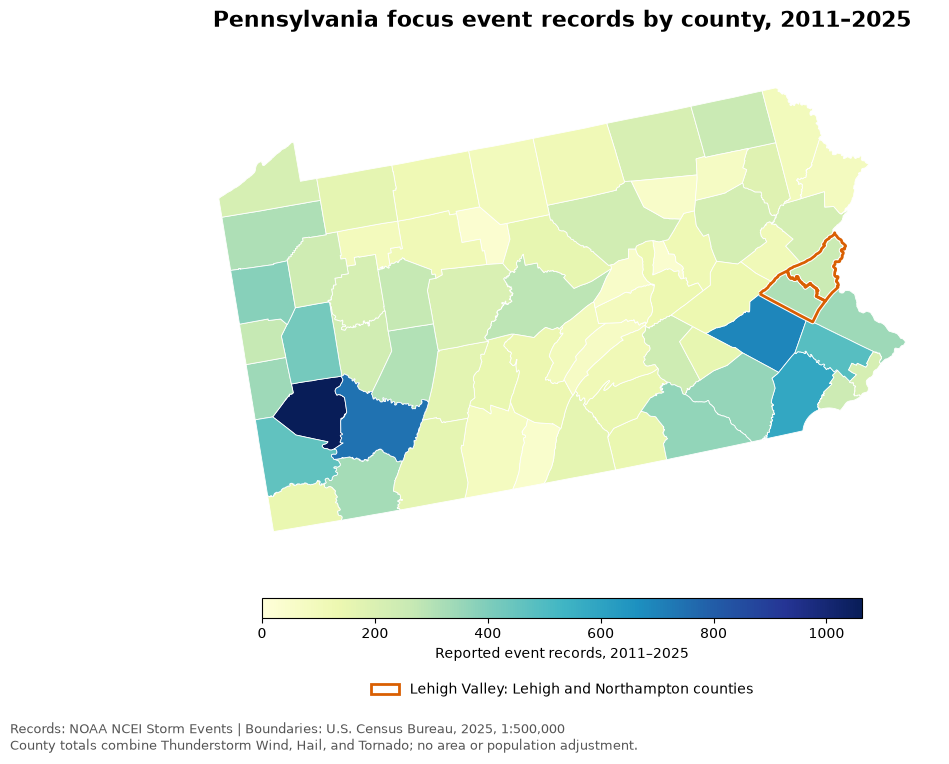

Map coordinate system: ESRI:102003
Saved map: c:\Users\rcolo\OneDrive\Desktop\Pennsylvania-Severe-Weather-Atlas\outputs\maps\pa_county_total_records_2011_2025.png


In [6]:
MAP_CRS = "ESRI:102003"

pa_county_map = pa_county_summary.to_crs(MAP_CRS)

lehigh_valley_map = pa_county_map.loc[
    pa_county_map["county_fips"].isin(["42077", "42095"])
].copy()

fig = plt.figure(figsize=(12, 8), facecolor="white")
ax = fig.add_axes([0.03, 0.27, 0.94, 0.61])
cax = fig.add_axes([0.25, 0.19, 0.50, 0.025])

pa_county_map.plot(
    column="total_records",
    cmap="YlGnBu",
    vmin=0,
    vmax=pa_county_map["total_records"].max(),
    edgecolor="white",
    linewidth=0.6,
    ax=ax,
    cax=cax,
    legend=True,
    legend_kwds={
        "label": "Reported event records, 2011–2025",
        "orientation": "horizontal",
    },
)

lehigh_valley_map.boundary.plot(
    ax=ax, color="white", linewidth=3.5, zorder=2
)
lehigh_valley_map.boundary.plot(
    ax=ax, color="#D95F02", linewidth=2, zorder=3
)

ax.set_axis_off()

fig.suptitle(
    "Pennsylvania focus event records by county, 2011–2025",
    fontsize=16,
    fontweight="bold",
    y=0.95,
)

fig.legend(
    handles=[
        Patch(
            facecolor="none",
            edgecolor="#D95F02",
            linewidth=2,
            label="Lehigh Valley: Lehigh and Northampton counties",
        )
    ],
    loc="center",
    bbox_to_anchor=(0.5, 0.10),
    frameon=False,
)

fig.text(
    0.04, 0.025,
    "Records: NOAA NCEI Storm Events | Boundaries: U.S. Census Bureau, 2025, 1:500,000\n"
    "County totals combine Thunderstorm Wind, Hail, and Tornado; no area or population adjustment.",
    fontsize=9,
    color="#555555",
)

PROJECT_PATHS["maps"].mkdir(parents=True, exist_ok=True)
map_path = PROJECT_PATHS["maps"] / "pa_county_total_records_2011_2025.png"

fig.savefig(map_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print("Map coordinate system:", pa_county_map.crs)
print("Saved map:", map_path)

### County map interpretation

Larger combined record totals appear in parts of southwestern and southeastern Pennsylvania. Allegheny leads with 1,063 records, followed by Westmoreland with 745 and Berks with 692.

The orange outlines identify Lehigh and Northampton counties, which contain 313 and 251 records, respectively.

Thunderstorm wind contributes 12,630 of the 15,399 statewide records. Separate maps will help us examine the geographic patterns of hail and tornado records alongside wind.


## Comparing county patterns by event type

We will create separate county maps for thunderstorm wind, hail, and tornado records.

Each panel uses its own color scale beginning at zero. Read each color bar carefully: the same shade can represent different counts across panels.

Orange outlines identify the Lehigh Valley. A small results table will identify the largest county count for each event type, including any ties.

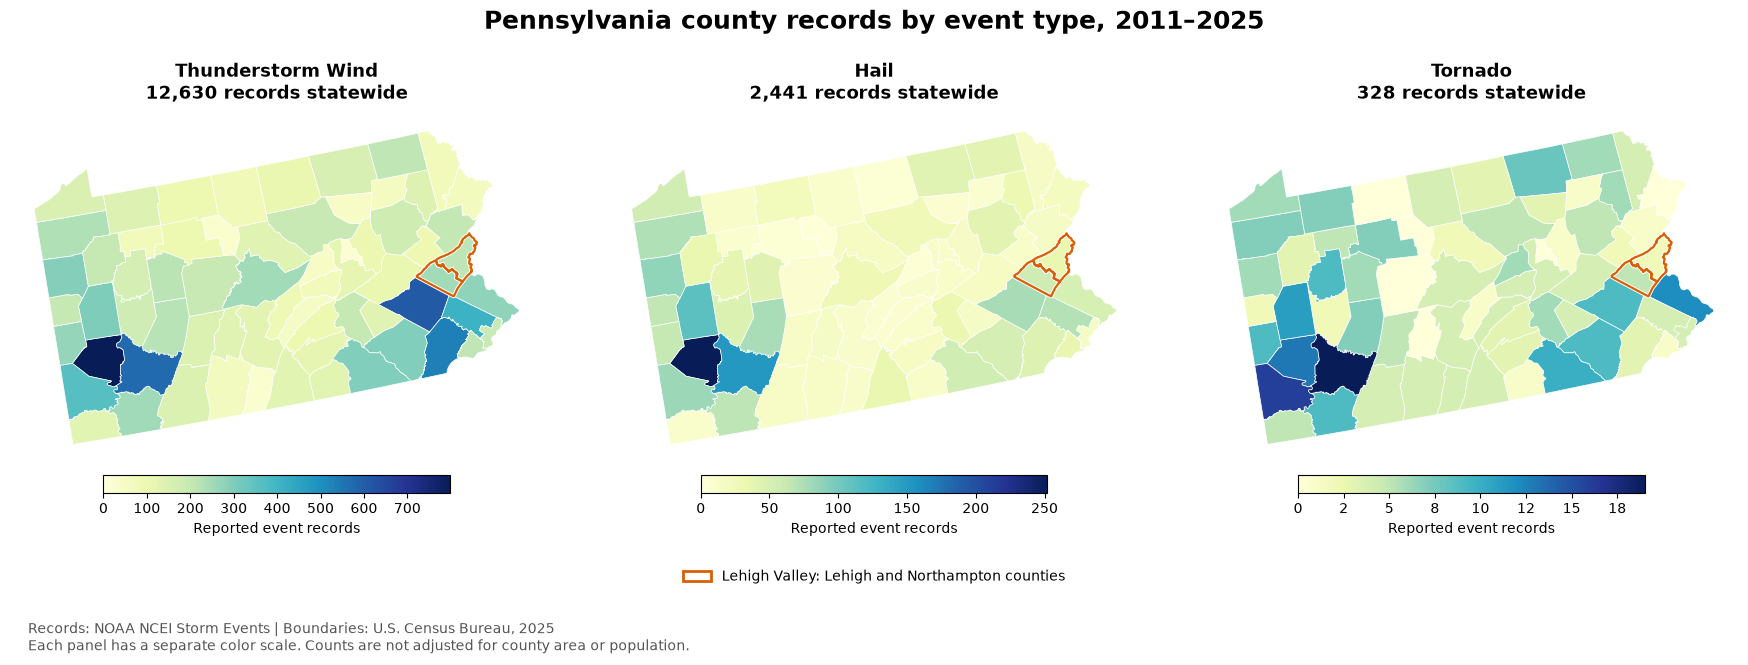

Saved map: c:\Users\rcolo\OneDrive\Desktop\Pennsylvania-Severe-Weather-Atlas\outputs\maps\pa_county_records_by_event_type_2011_2025.png


,event_type,leading_counties,largest_county_count
0,Thunderstorm Wind,Allegheny,798
1,Hail,Allegheny,252
2,Tornado,Westmoreland,19


In [7]:
fig, axes = plt.subplots(
    1, 3, figsize=(18, 7), facecolor="white"
)

county_peaks = []

for ax, event_type in zip(axes, FOCUS_EVENT_TYPES):
    maximum = int(pa_county_map[event_type].max())
    statewide_total = int(pa_county_map[event_type].sum())

    pa_county_map.plot(
        column=event_type,
        cmap="YlGnBu",
        vmin=0,
        vmax=maximum,
        edgecolor="white",
        linewidth=0.5,
        ax=ax,
        legend=True,
        legend_kwds={
            "label": "Reported event records",
            "orientation": "horizontal",
            "shrink": 0.9,
            "fraction": 0.045,
            "pad": 0.04,
            "format": "%.0f",
        },
    )

    lehigh_valley_map.boundary.plot(
        ax=ax, color="white", linewidth=3, zorder=2
    )
    lehigh_valley_map.boundary.plot(
        ax=ax, color="#D95F02", linewidth=1.6, zorder=3
    )

    ax.set_title(
        f"{event_type}\n{statewide_total:,} records statewide",
        fontsize=13,
        fontweight="bold",
        pad=12,
    )
    ax.set_axis_off()

    leading_counties = pa_county_map.loc[
        pa_county_map[event_type].eq(maximum), "county_name"
    ].sort_values()

    county_peaks.append({
        "event_type": event_type,
        "leading_counties": ", ".join(leading_counties),
        "largest_county_count": maximum,
    })

fig.suptitle(
    "Pennsylvania county records by event type, 2011–2025",
    fontsize=18,
    fontweight="bold",
    y=0.95,
)

fig.legend(
    handles=[
        Patch(
            facecolor="none",
            edgecolor="#D95F02",
            linewidth=2,
            label="Lehigh Valley: Lehigh and Northampton counties",
        )
    ],
    loc="center",
    bbox_to_anchor=(0.5, 0.14),
    frameon=False,
)

fig.text(
    0.03, 0.035,
    "Records: NOAA NCEI Storm Events | Boundaries: U.S. Census Bureau, 2025\n"
    "Each panel has a separate color scale. Counts are not adjusted for county area or population.",
    fontsize=10,
    color="#555555",
)

fig.subplots_adjust(
    left=0.02, right=0.98, bottom=0.26, top=0.81, wspace=0.12
)

map_path = (
    PROJECT_PATHS["maps"]
    / "pa_county_records_by_event_type_2011_2025.png"
)

fig.savefig(map_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved map:", map_path)
pd.DataFrame(county_peaks)

### County patterns by event type

The largest county counts were:

| Event type | Leading county | Reported records |
| --- | --- | ---: |
| Thunderstorm Wind | Allegheny | 798 |
| Hail | Allegheny | 252 |
| Tornado | Westmoreland | 19 |

Allegheny leads the wind and hail counts, while Westmoreland leads tornado records. Separating the event types reveals differences that the combined map can obscure.

Each panel uses its own color scale. Similar shading across panels does not imply similar record counts.

## Comparing Lehigh and Northampton counties

We will examine the wind, hail, and tornado counts within each Lehigh Valley county and check that their combined total matches our local dataset.

Lehigh's larger overall total does not necessarily mean it has more records of every event type.

In [9]:
lehigh_valley_county_counts = (
    lehigh_valley_map[
        [
            "county_fips",
            "county_name",
            *FOCUS_EVENT_TYPES,
            "total_records",
        ]
    ]
    .sort_values("county_name")
    .reset_index(drop=True)
)

local_county_total = int(
    lehigh_valley_county_counts["total_records"].sum()
)
local_dataset_total = int(
    pa_focus_events["is_lehigh_valley"].sum()
)

print(f"Records in local county table: {local_county_total:,}")
print(
    "Matches Lehigh Valley subset:",
    local_county_total == local_dataset_total,
)

lehigh_valley_county_counts

Records in local county table: 564
Matches Lehigh Valley subset: True


,county_fips,county_name,Thunderstorm Wind,Hail,Tornado,total_records
0,42077,Lehigh,250,58,5,313
1,42095,Northampton,214,35,2,251


### Lehigh Valley county comparison

The county totals reconcile to all 564 Lehigh Valley records: 313 in Lehigh and 251 in Northampton.

Lehigh has more thunderstorm wind records (250 versus 214), hail records (58 versus 35), and tornado records (5 versus 2). Thunderstorm wind is the largest category in both counties.

These comparisons describe reported records accumulated across 2011–2025.

## Saving county analysis outputs

We will save statewide county counts, the Lehigh Valley comparison, and the leading-county table as CSV files.

We will also save county boundaries with their record counts in two geographic formats:

- **GeoJSON:** longitude and latitude coordinates for use in web maps.
- **GeoPackage:** the Albers projection used for our notebook maps.

The geographic layers will include a flag identifying Lehigh and Northampton counties.

In [10]:
county_layer = pa_county_map[
    [
        "county_fips",
        "county_name",
        *FOCUS_EVENT_TYPES,
        "total_records",
        "geometry",
    ]
].copy()

county_layer["is_lehigh_valley"] = county_layer["county_fips"].isin(
    ["42077", "42095"]
)

county_table = pd.DataFrame(county_layer.drop(columns="geometry"))
county_peak_summary = pd.DataFrame(county_peaks)

county_tables = {
    "pa_county_focus_counts_2011_2025.csv": county_table,
    "lehigh_valley_county_focus_counts_2011_2025.csv": (
        lehigh_valley_county_counts
    ),
    "pa_county_event_peaks_2011_2025.csv": county_peak_summary,
}

county_saved_outputs = []

for filename, table in county_tables.items():
    output_path = PROJECT_PATHS["tables"] / filename
    table.to_csv(output_path, index=False)

    county_saved_outputs.append({
        "file": filename,
        "file_exists": output_path.is_file(),
        "file_size_bytes": output_path.stat().st_size,
    })

county_geojson_path = (
    PROJECT_PATHS["maps"] / "pa_county_focus_counts_2011_2025.geojson"
)
county_gpkg_path = (
    PROJECT_PATHS["maps"] / "pa_county_focus_counts_2011_2025.gpkg"
)

county_layer.to_crs("EPSG:4326").to_file(
    county_geojson_path,
    driver="GeoJSON",
    index=False,
)

county_layer.to_file(
    county_gpkg_path,
    layer="county_focus_counts",
    driver="GPKG",
    index=False,
)

for output_path in [county_geojson_path, county_gpkg_path]:
    county_saved_outputs.append({
        "file": output_path.name,
        "file_exists": output_path.is_file(),
        "file_size_bytes": output_path.stat().st_size,
    })

pd.DataFrame(county_saved_outputs)

,file,file_exists,file_size_bytes
0,pa_county_focus_counts_2011_2025.csv,True,2354
1,lehigh_valley_county_focus_counts_2011_2025.csv,True,129
2,pa_county_event_peaks_2011_2025.csv,True,128
3,pa_county_focus_counts_2011_2025.geojson,True,514150
4,pa_county_focus_counts_2011_2025.gpkg,True,442368


### County outputs saved

Three CSV tables and two geographic layers were saved successfully. All five files exist and contain data.

Next, we will reload them to check that table values and map attributes were preserved, coordinate systems match the intended exports, and county geometries remain present, nonempty, and valid.

In [11]:
county_export_checks = []

for filename, expected_table in county_tables.items():
    output_path = PROJECT_PATHS["tables"] / filename

    restored_table = pd.read_csv(
        output_path,
        dtype=(
            {"county_fips": "string"}
            if "county_fips" in expected_table.columns
            else None
        ),
    )

    pd.testing.assert_frame_equal(
        pd.DataFrame(expected_table).reset_index(drop=True),
        restored_table,
        check_dtype=False,
    )

    county_export_checks.append({
        "file": filename,
        "rows": len(restored_table),
        "values_match": True,
        "crs_matches": "Not applicable",
        "geometries_valid": "Not applicable",
    })

geographic_exports = [
    (county_geojson_path, county_layer.to_crs("EPSG:4326")),
    (county_gpkg_path, county_layer),
]

for output_path, expected_layer in geographic_exports:
    if output_path.suffix == ".gpkg":
        restored_layer = gpd.read_file(
            output_path, layer="county_focus_counts"
        )
    else:
        restored_layer = gpd.read_file(output_path)

    expected_attributes = pd.DataFrame(
        expected_layer.drop(columns=expected_layer.geometry.name)
    )
    restored_attributes = pd.DataFrame(
        restored_layer.drop(columns=restored_layer.geometry.name)
    )

    for attributes in [expected_attributes, restored_attributes]:
        attributes["county_fips"] = attributes["county_fips"].astype("string")

    pd.testing.assert_frame_equal(
        expected_attributes.sort_values("county_fips").reset_index(drop=True),
        restored_attributes.sort_values("county_fips").reset_index(drop=True),
        check_dtype=False,
    )

    crs_matches = restored_layer.crs == expected_layer.crs
    geometries_valid = bool(
        restored_layer.geometry.notna().all()
        and not restored_layer.geometry.is_empty.any()
        and restored_layer.geometry.is_valid.all()
    )

    if not crs_matches or not geometries_valid:
        raise ValueError(f"Geographic checks failed: {output_path.name}")

    county_export_checks.append({
        "file": output_path.name,
        "rows": len(restored_layer),
        "values_match": True,
        "crs_matches": crs_matches,
        "geometries_valid": geometries_valid,
    })

pd.DataFrame(county_export_checks)

,file,rows,values_match,crs_matches,geometries_valid
0,pa_county_focus_counts_2011_2025.csv,67,True,Not applicable,Not applicable
1,lehigh_valley_county_focus_counts_2011_2025.csv,2,True,Not applicable,Not applicable
2,pa_county_event_peaks_2011_2025.csv,3,True,Not applicable,Not applicable
3,pa_county_focus_counts_2011_2025.geojson,67,True,True,True
4,pa_county_focus_counts_2011_2025.gpkg,67,True,True,True


### Export verification

All three CSV tables preserved their values: 67 statewide county rows, two Lehigh Valley county rows, and three event-type leaders.

Both geographic exports contain 67 counties with matching attributes and the intended coordinate systems. Their geometries are present, nonempty, and valid.

## Recording the boundary source

We will add the Census county boundaries to our data-source registry.

A separate boundary manifest will record the source URL, filename, file size, coordinate systems, and SHA-256 checksum. The checksum lets us check later whether the source archive has changed.

In [12]:
BOUNDARY_SOURCE_ID = "census_county_boundaries"

registry_path = PROJECT_PATHS["tables"] / "data_source_registry.csv"
source_registry = pd.read_csv(registry_path)

boundary_source = pd.DataFrame([{
    "source_id": BOUNDARY_SOURCE_ID,
    "source_name": (
        f"Cartographic Boundary Files: Counties "
        f"({BOUNDARY_YEAR}, 1:500,000)"
    ),
    "provider": "U.S. Census Bureau",
    "source_url": boundary_url,
    "planned_use": "County reference boundaries for Pennsylvania mapping",
    "status": "67 PA counties matched; geographic exports verified",
}])

source_registry = pd.concat(
    [
        source_registry.loc[
            source_registry["source_id"].ne(BOUNDARY_SOURCE_ID)
        ],
        boundary_source,
    ],
    ignore_index=True,
)

boundary_manifest = pd.DataFrame([{
    "source_id": BOUNDARY_SOURCE_ID,
    "boundary_year": BOUNDARY_YEAR,
    "filename": boundary_path.name,
    "source_url": boundary_url,
    "file_size_bytes": boundary_path.stat().st_size,
    "sha256": hashlib.sha256(boundary_path.read_bytes()).hexdigest(),
    "checked_at_utc": datetime.now(timezone.utc).isoformat(),
    "source_crs": str(pa_counties.crs),
    "map_crs": str(pa_county_map.crs),
    "pa_county_rows": len(pa_counties),
}])

boundary_manifest_path = (
    PROJECT_PATHS["tables"]
    / f"census_county_boundary_manifest_{BOUNDARY_YEAR}.csv"
)

boundary_manifest.to_csv(boundary_manifest_path, index=False)
source_registry.to_csv(registry_path, index=False)

print("Boundary manifest saved to:", boundary_manifest_path)
print("Source registry saved to:", registry_path)

source_registry[["source_id", "source_name", "status"]]

Boundary manifest saved to: c:\Users\rcolo\OneDrive\Desktop\Pennsylvania-Severe-Weather-Atlas\reports\tables\census_county_boundary_manifest_2025.csv
Source registry saved to: c:\Users\rcolo\OneDrive\Desktop\Pennsylvania-Severe-Weather-Atlas\reports\tables\data_source_registry.csv


,source_id,source_name,status
0,noaa_storm_events,Storm Events Database,2011-2025 PA focus subset prepared; selected f...
1,census_county_boundaries,"Cartographic Boundary Files: Counties (2025, 1...",67 PA counties matched; geographic exports ver...


## Notebook 04 — Summary

All 15,399 Pennsylvania focus records from 2011–2025 matched the 67 county boundaries. The county aggregation preserved the full record total.

### Main findings

Allegheny had the largest combined count, with 1,063 records. The leading county differed by event type:

| Event type | Leading county | Records |
| --- | --- | ---: |
| Thunderstorm Wind | Allegheny | 798 |
| Hail | Allegheny | 252 |
| Tornado | Westmoreland | 19 |

The Lehigh Valley contained 564 records: 313 in Lehigh County and 251 in Northampton County. Lehigh had more records in all three categories, and thunderstorm wind dominated both counties.

### Saved outputs and verification

Two county map figures, three CSV tables, and GeoJSON and GeoPackage layers were saved.

Reloading confirmed that table values and geographic attributes were preserved. Both geographic exports contained 67 counties with the intended coordinate systems and valid, nonempty geometries.

The source registry now includes NOAA Storm Events and Census county boundaries. A boundary manifest records the source archive and its SHA-256 checksum.

### Interpretation limits

These maps describe reported event records without adjustment for county area or population. They do not establish county-level weather risk.

The 2025 Census boundary layer serves as the geographic reference for the entire 2011–2025 study period.